In [11]:
# from google.colab import files
# import io

# uploaded = files.upload()

# file_name = list(uploaded.keys())[0]

In [12]:
# ── Setup e carga ───────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             classification_report, ConfusionMatrixDisplay)
import pickle

sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv(file_name)

print(f"Shape: {df.shape}")
df.head()

Shape: (4610, 13)


,sex,age_cat,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,two_year_recid,sex_encoded,c_charge_degree_encoded,race_encoded,age_cat_encoded
0,Male,25 - 45,African-American,0,0,0,0,F,1,1,1,1,1
1,Male,Less than 25,African-American,0,0,1,4,F,1,1,1,1,0
2,Male,Less than 25,African-American,0,1,0,1,F,0,1,1,1,0
3,Male,25 - 45,Caucasian,0,0,0,14,F,1,1,1,0,1
4,Female,25 - 45,Caucasian,0,0,0,0,M,0,0,0,0,1


In [13]:
# ── Features e target ──────────────────────────────────

FEATURES = [
    'sex_encoded',
    'age_cat_encoded',
    'race_encoded',
    'juv_fel_count',
    'juv_misd_count',
    'juv_other_count',
    'priors_count',
    'c_charge_degree_encoded',
]

TARGET = 'two_year_recid'

X    = df[FEATURES]
y    = df[TARGET]
race = df['race']

print(f"Shape X: {X.shape}")
print(f"\nBalanceamento target:\n{y.value_counts(normalize=True).mul(100).round(2)}")

Shape X: (4610, 8)

Balanceamento target:
two_year_recid
0    52.43
1    47.57
Name: proportion, dtype: float64


In [14]:
# ── Split ───────────────────────────────────────────────
# XGBoost não requer scaling

X_train, X_test, y_train, y_test, race_train, race_test = train_test_split(
    X, y, race,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"\nBalanceamento treino:\n{y_train.value_counts(normalize=True).mul(100).round(2)}")
print(f"\nBalanceamento teste:\n{y_test.value_counts(normalize=True).mul(100).round(2)}")

Treino: (3688, 8) | Teste: (922, 8)

Balanceamento treino:
two_year_recid
0    52.44
1    47.56
Name: proportion, dtype: float64

Balanceamento teste:
two_year_recid
0    52.39
1    47.61
Name: proportion, dtype: float64


In [15]:
# ── CÉLULA 4 · Tuning ampliado XGBoost ────────────────────────────
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')

param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [3, 4, 5, 6, 7],
    'learning_rate'    : [0.001, 0.01, 0.05, 0.1, 0.3],
    'subsample'        : [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree' : [0.6, 0.7, 0.8, 1.0],
    'min_child_weight' : [1, 3, 5, 10],
    'gamma'            : [0, 0.1, 0.3, 0.5],
    'reg_alpha'        : [0, 0.01, 0.1, 1],
    'reg_lambda'       : [0.1, 1, 5, 10],
    'scale_pos_weight' : [1, 2],
}

random_search = RandomizedSearchCV(
    estimator  = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_distributions = param_dist,
    n_iter       = 60,
    scoring      = 'roc_auc',
    cv           = 5,
    n_jobs       = -1,
    verbose      = 1,
    random_state = 42,
    return_train_score = True
)

random_search.fit(X_train, y_train)

print(f"Melhores hiperparâmetros: {random_search.best_params_}")
print(f"Melhor ROC-AUC (cv):      {random_search.best_score_:.4f}")

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Melhores hiperparâmetros: {'subsample': 1.0, 'scale_pos_weight': 1, 'reg_lambda': 10, 'reg_alpha': 0.01, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.8}
Melhor ROC-AUC (cv):      0.7285


In [16]:
# ── CÉLULA 5 · Avaliação do melhor modelo ─────────────────────────

model = random_search.best_estimator_

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=== DESEMPENHO GERAL ===")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

=== DESEMPENHO GERAL ===

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.72      0.69       483
           1       0.66      0.60      0.63       439

    accuracy                           0.66       922
   macro avg       0.66      0.66      0.66       922
weighted avg       0.66      0.66      0.66       922



In [17]:
# ── CÉLULA 6 · Métricas de performance ────────────────────────────

metrics = {
    'Acurácia'  : accuracy_score(y_test, y_pred),
    'Precisão'  : precision_score(y_test, y_pred),
    'Recall'    : recall_score(y_test, y_pred),
    'F1-Score'  : f1_score(y_test, y_pred),
    'ROC-AUC'   : roc_auc_score(y_test, y_prob),
}

print("=== MÉTRICAS DE PERFORMANCE ===")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

=== MÉTRICAS DE PERFORMANCE ===
  Acurácia: 0.6649
  Precisão: 0.6633
  Recall: 0.6014
  F1-Score: 0.6308
  ROC-AUC: 0.7214


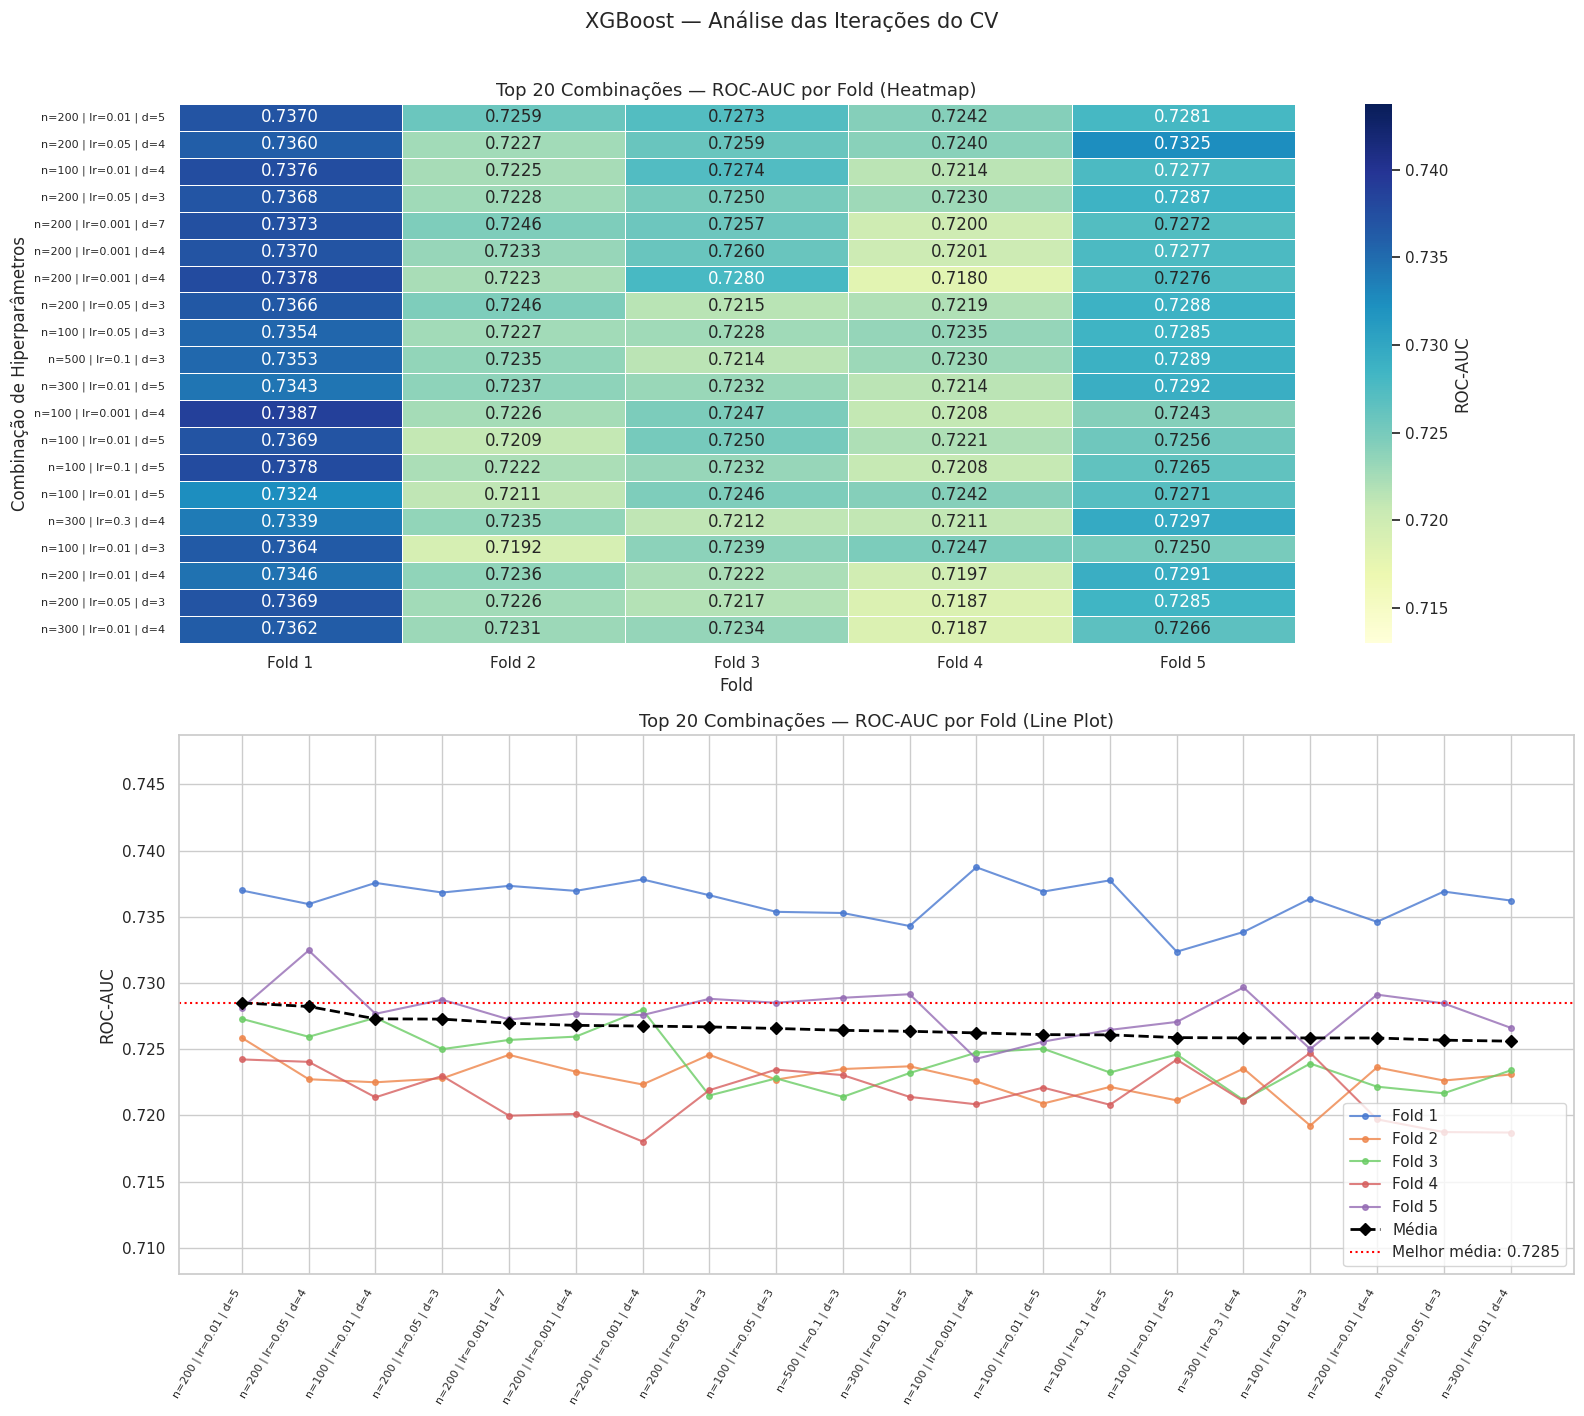

In [18]:
# ── CÉLULA 7 · Iterações do CV ────────────────────────────────────

cv_results = pd.DataFrame(random_search.cv_results_)
fold_cols  = [f'split{i}_test_score' for i in range(5)]

# Top 20 combinações por ROC-AUC médio
top20 = (cv_results
         .nlargest(20, 'mean_test_score')
         .reset_index(drop=True))

top20['label'] = top20.apply(
    lambda r: f"n={r['param_n_estimators']} | lr={r['param_learning_rate']} | d={r['param_max_depth']}",
    axis=1
)

scores_matrix = top20[fold_cols].values

fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# 7a. Heatmap
heatmap_data = pd.DataFrame(
    scores_matrix,
    index=top20['label'],
    columns=[f'Fold {i+1}' for i in range(5)]
)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.4f',
    cmap='YlGnBu',
    linewidths=0.5,
    ax=axes[0],
    vmin=scores_matrix.min() - 0.005,
    vmax=scores_matrix.max() + 0.005,
    cbar_kws={'label': 'ROC-AUC'}
)
axes[0].set_title('Top 20 Combinações — ROC-AUC por Fold (Heatmap)', fontsize=13)
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Combinação de Hiperparâmetros')
axes[0].tick_params(axis='y', labelsize=8)

# 7b. Line plot
fold_colors = sns.color_palette('muted', 5)
x = range(len(top20))

for i, (fold_col, color) in enumerate(zip(fold_cols, fold_colors)):
    axes[1].plot(x, top20[fold_col].values,
                 marker='o', markersize=4,
                 label=f'Fold {i+1}',
                 color=color, linewidth=1.5, alpha=0.8)

axes[1].plot(x, top20['mean_test_score'].values,
             marker='D', markersize=6,
             label='Média', color='black',
             linewidth=2, linestyle='--', zorder=5)

axes[1].axhline(y=random_search.best_score_, color='red',
                linestyle=':', linewidth=1.5,
                label=f'Melhor média: {random_search.best_score_:.4f}')
axes[1].set_xticks(x)
axes[1].set_xticklabels(top20['label'], rotation=60, ha='right', fontsize=8)
axes[1].set_title('Top 20 Combinações — ROC-AUC por Fold (Line Plot)', fontsize=13)
axes[1].set_ylabel('ROC-AUC')
axes[1].legend(loc='lower right')
axes[1].set_ylim(scores_matrix.min() - 0.01, scores_matrix.max() + 0.01)

plt.suptitle('XGBoost — Análise das Iterações do CV', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('/content/xgb_cv_iterations.png', dpi=150, bbox_inches='tight')
plt.show()

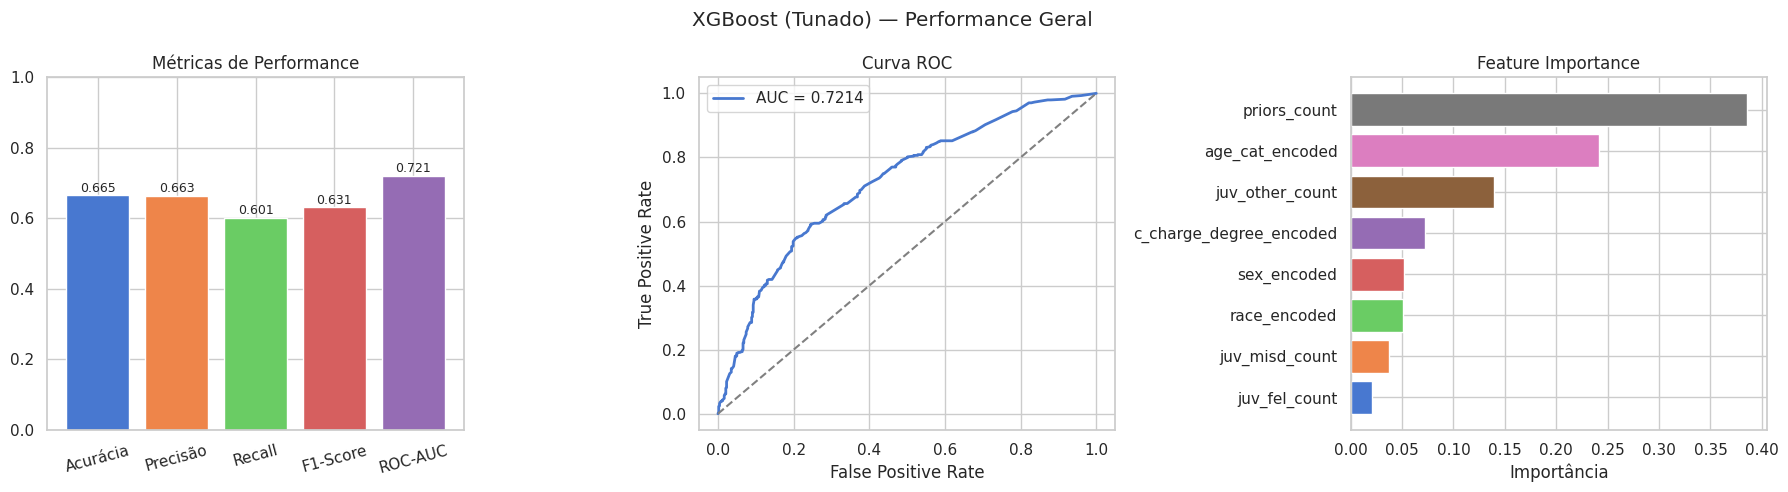

In [19]:
# ── CÉLULA 8 · Visualizações de performance ───────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 8a. Métricas em barras
axes[0].bar(metrics.keys(), metrics.values(), color=sns.color_palette('muted'))
axes[0].set_title('Métricas de Performance')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(metrics.values()):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

# 8b. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#4878CF', lw=2,
             label=f"AUC = {metrics['ROC-AUC']:.4f}")
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# 8c. Feature Importance
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
axes[2].barh(importances.index, importances.values, color=sns.color_palette('muted'))
axes[2].set_title('Feature Importance')
axes[2].set_xlabel('Importância')

plt.suptitle('XGBoost (Tunado) — Performance Geral')
plt.tight_layout()
plt.savefig('/content/xgb_performance.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ── CÉLULA 9 · Exportar modelo e resultados ────────────────────────

with open('/content/xgb_model.pkl', 'wb') as f:
    pickle.dump(model, f)

df_metrics = pd.DataFrame([{
    'modelo'    : 'XGBoost',
    'subsample' : '100pct',
    'acuracia'  : metrics['Acurácia'],
    'precisao'  : metrics['Precisão'],
    'recall'    : metrics['Recall'],
    'f1'        : metrics['F1-Score'],
    'roc_auc'   : metrics['ROC-AUC'],
}])

df_metrics.to_csv('/content/xgb_results.csv', index=False)

print("Exportados:")
print("xgb_model.pkl")
print("xgb_results.csv")
print(f"\n{df_metrics.to_string(index=False)}")

Exportados:
xgb_model.pkl
xgb_results.csv

 modelo subsample  acuracia  precisao   recall       f1  roc_auc
XGBoost    100pct  0.664859  0.663317 0.601367 0.630824 0.721362
